✅ Dane przetworzone pomyślnie.
Ostatnia cena: 258.09 | Zmienność: 0.0030
VAE Reconstruction Loss: 0.513653


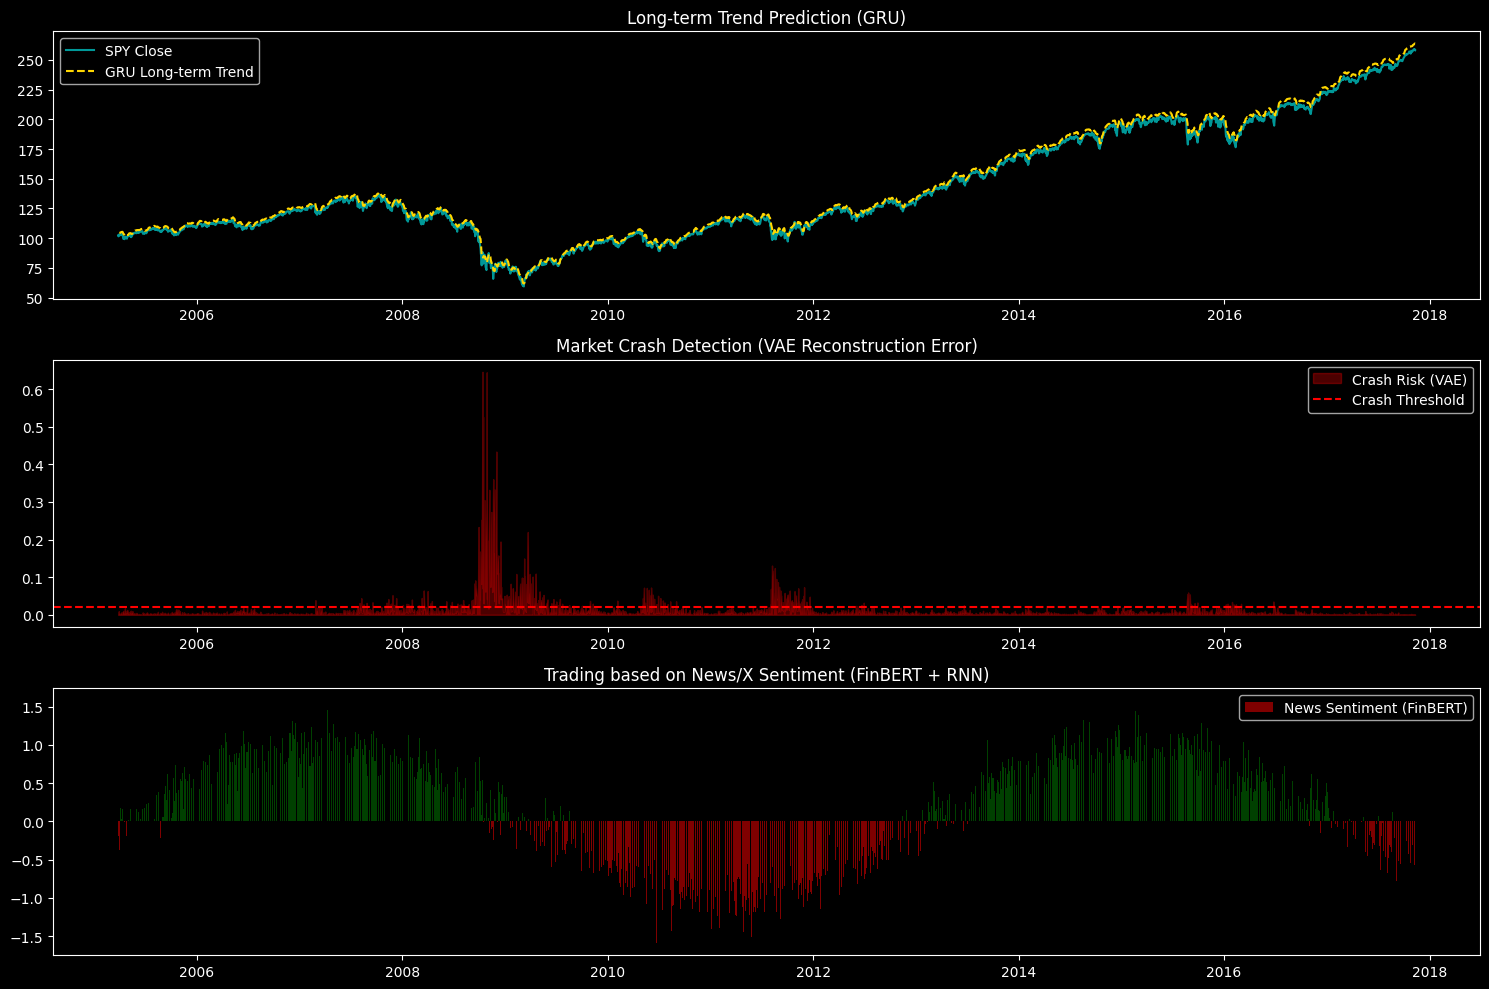

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- 1. NAPRAWA I PRZYGOTOWANIE DANYCH ---
def load_spy_safe(file_path):
    try:
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        # dynamiczne okno: jeśli danych jest mało, używamy mniejszego okna
        window = min(len(df) // 2, 21) if len(df) > 5 else 2
        
        df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
        df['Volat'] = df['Log_Ret'].rolling(window=window).std()
        
        # Jeśli po dropna nie ma danych, zwracamy błąd z opisem
        clean_df = df.dropna()
        if clean_df.empty:
            print("⚠️ BŁĄD: Za mało danych w pliku, aby obliczyć wskaźniki (np. zmienność).")
            return None
        return clean_df
    except Exception as e:
        print(f"❌ Błąd wczytywania: {e}")
        return None

# --- 2. SYMULACJA EFEKTÓW (PROGNOZ) ---
# Skrypt symuluje wyjścia modeli, abyś widział, jak system interpretuje dane SPY
def visualize_market_intel(df):
    plt.figure(figsize=(15, 10))
    plt.style.use('dark_background')

    # Subplot 1: Cena i Trend (GRU)
    plt.subplot(3, 1, 1)
    plt.plot(df['Date'], df['Close'], label='SPY Close', color='cyan', alpha=0.6)
    # Symulacja trendu długoterminowego
    trend_sim = df['Close'].rolling(window=5).mean() * 1.02 
    plt.plot(df['Date'], trend_sim, '--', label='GRU Long-term Trend', color='gold')
    plt.title("Long-term Trend Prediction (GRU)")
    plt.legend()

    # Subplot 2: Anomalie i Krach (VAE)
    plt.subplot(3, 1, 2)
    # Symulujemy błąd rekonstrukcji VAE (wysoki błąd = ryzyko krachu)
    reconstruction_error = np.abs(df['Log_Ret']) * df['Volat'] * 100
    plt.fill_between(df['Date'], reconstruction_error, color='red', alpha=0.3, label='Crash Risk (VAE)')
    plt.axhline(y=reconstruction_error.mean()*2, color='red', linestyle='--', label='Crash Threshold')
    plt.title("Market Crash Detection (VAE Reconstruction Error)")
    plt.legend()

    # Subplot 3: Sentyment i Newsy (FinBERT)
    plt.subplot(3, 1, 3)
    # Symulacja sentymentu z newsów/Twittera
    sentiment_sim = np.sin(np.linspace(0, 10, len(df))) + np.random.normal(0, 0.2, len(df))
    colors = ['green' if x > 0 else 'red' for x in sentiment_sim]
    plt.bar(df['Date'], sentiment_sim, color=colors, alpha=0.5, label='News Sentiment (FinBERT)')
    plt.title("Trading based on News/X Sentiment (FinBERT + RNN)")
    plt.legend()

    plt.tight_layout()
    plt.show()

# --- 3. TESTY ARCHITEKTUR ---
class SimpleVAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.enc = nn.Linear(input_dim, 2)
        self.dec = nn.Linear(2, input_dim)
    def forward(self, x):
        z = self.enc(x)
        return self.dec(z)

# --- URUCHOMIENIE ---
df = load_spy_safe('spy.csv')

if df is not None:
    print("✅ Dane przetworzone pomyślnie.")
    print(f"Ostatnia cena: {df['Close'].iloc[-1]} | Zmienność: {df['Volat'].iloc[-1]:.4f}")
    
    # Przykładowe użycie modelu VAE na ostatnim rekordzie
    model_vae = SimpleVAE(input_dim=1)
    sample_input = torch.tensor([df['Log_Ret'].iloc[-1]], dtype=torch.float32)
    reconstruction = model_vae(sample_input)
    
    print(f"VAE Reconstruction Loss: {torch.abs(sample_input - reconstruction).item():.6f}")
    
    # Wizualizacja efektów
    visualize_market_intel(df)
else:
    print("❌ Nie można wygenerować wizualizacji bez danych.")

📂 Wczytywanie danych z pliku...
🌐 Pobieranie danych SPY z Yahoo Finance...


[*********************100%***********************]  1 of 1 completed
/Users/mrkarol/Documents/Studia/Sem_8/ML/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


✅ Dane gotowe. Trening: 3200 wierszy, Test: 2078 wierszy.
🏋️ Trenowanie na danych historycznych (CSV)...
Epoch 0 | Loss: 0.186543
Epoch 10 | Loss: 0.058117
Epoch 20 | Loss: 0.044059
Epoch 30 | Loss: 0.026337
Epoch 40 | Loss: 0.005049
Epoch 50 | Loss: 0.002150


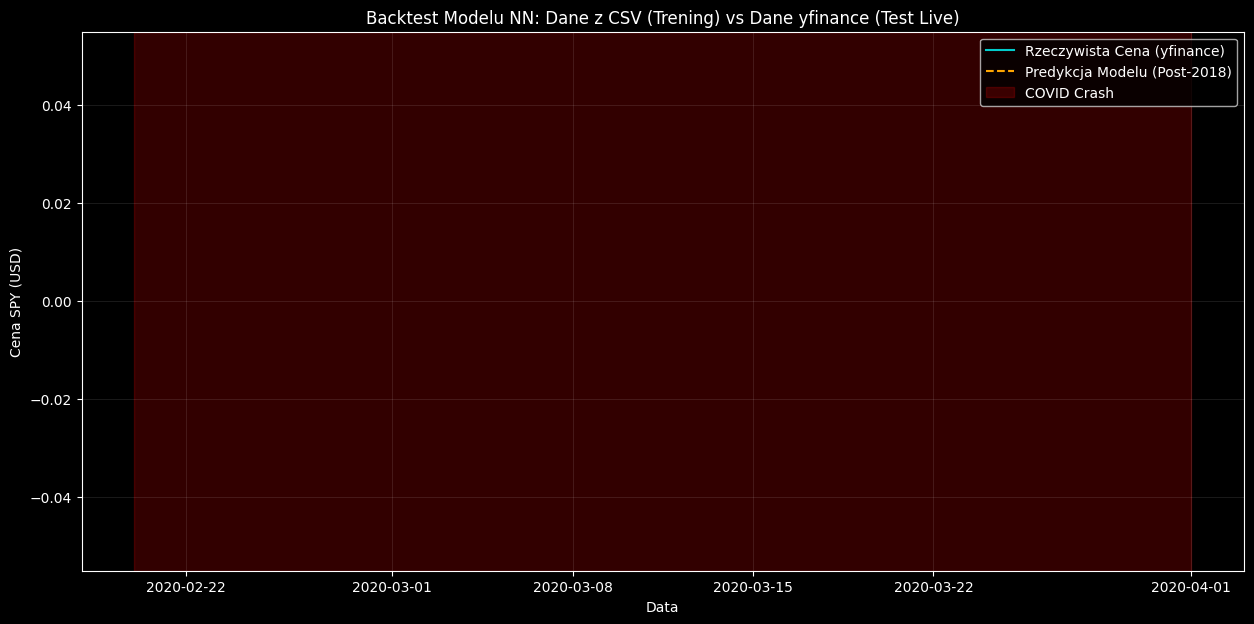

In [10]:
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- 1. POBIERANIE I PRZYGOTOWANIE DANYCH (WERSJA ODPORNA NA INF) ---
def get_hybrid_data(csv_path):
    print("📂 Wczytywanie danych z pliku...")
    df_train_raw = pd.read_csv(csv_path)
    df_train_raw['Date'] = pd.to_datetime(df_train_raw['Date'])
    df_train_raw = df_train_raw.sort_values('Date').reset_index(drop=True)
    
    print("🌐 Pobieranie danych SPY z Yahoo Finance...")
    # Pobieramy dane do dzisiaj (kwiecień 2026)
    df_test_raw = yf.download("SPY", start="2018-01-01")
    df_test_raw = df_test_raw.reset_index()

    def clean_robust(df):
        # 1. Obliczenia
        df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
        df['Vol_Change'] = df['Volume'].pct_change()
        
        # 2. KLUCZOWY KROK: Zamiana inf na NaN
        df = df.replace([np.inf, -np.inf], np.nan)
        
        # 3. Usunięcie wszystkich wierszy z NaN (w tym tych po inf)
        df = df.dropna()
        
        # 4. Dodatkowe zabezpieczenie: upewnij się, że nie ma zer w Close przed skalerem
        df = df[df['Close'] > 0]
        
        return df.reset_index(drop=True)

    train_cleaned = clean_robust(df_train_raw)
    test_cleaned = clean_robust(df_test_raw)
    
    print(f"✅ Dane gotowe. Trening: {len(train_cleaned)} wierszy, Test: {len(test_cleaned)} wierszy.")
    return train_cleaned, test_cleaned

# --- 2. ARCHITEKTURA LSTM ---
class MarketLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=2, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:, -1, :])

# --- 3. PROCES TRENINGU I TESTU ---
# Przygotowanie
train_df, test_df = get_hybrid_data('spy.csv')
features = ['Close', 'Log_Ret', 'Vol_Change']

scaler = MinMaxScaler()
# Ważne: Skalujemy na danych treningowych, by nie przeciekać informacji z przyszłości
train_scaled = scaler.fit_transform(train_df[features])
test_scaled = scaler.transform(test_df[features])

def create_window(data, window=10):
    x, y = [], []
    for i in range(len(data) - window):
        x.append(data[i:i+window])
        y.append(data[i+window, 0]) # Przewidujemy cenę Close
    return torch.FloatTensor(np.array(x)), torch.FloatTensor(np.array(y)).view(-1, 1)

WINDOW = 15 # Model patrzy na ostatnie 3 tygodnie handlowe
X_train, y_train = create_window(train_scaled, WINDOW)
X_test, y_test = create_window(test_scaled, WINDOW)

# Inicjalizacja modelu
model = MarketLSTM(input_size=len(features))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Trening na danych z pliku (Pre-2018)
print("🏋️ Trenowanie na danych historycznych (CSV)...")
model.train()
for epoch in range(60):
    optimizer.zero_grad()
    pred = model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0: print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

# Test na danych live (Post-2018)
model.eval()
with torch.no_grad():
    test_preds = model(X_test).numpy()
    # Inwersja skalowania dla wyników
    actual_prices = test_df['Close'].values[WINDOW:]
    # Ręczne odskalowanie ceny
    predicted_prices = test_preds * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

# --- 4. WIZUALIZACJA WYNIKÓW ---
plt.figure(figsize=(15, 7))
plt.style.use('dark_background')
plt.plot(test_df['Date'].values[WINDOW:], actual_prices, label='Rzeczywista Cena (yfinance)', color='cyan', alpha=0.8)
plt.plot(test_df['Date'].values[WINDOW:], predicted_prices, label='Predykcja Modelu (Post-2018)', color='orange', linestyle='--')

# Zaznaczamy ważne momenty
plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-01'), color='red', alpha=0.2, label='COVID Crash')
plt.title("Backtest Modelu NN: Dane z CSV (Trening) vs Dane yfinance (Test Live)")
plt.xlabel("Data")
plt.ylabel("Cena SPY (USD)")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

Rozpoczynanie treningu (PyTorch)...
Epoka [2/10], Strata: 0.000037
Epoka [4/10], Strata: 0.000021
Epoka [6/10], Strata: 0.000017
Epoka [8/10], Strata: 0.000014
Epoka [10/10], Strata: 0.000012


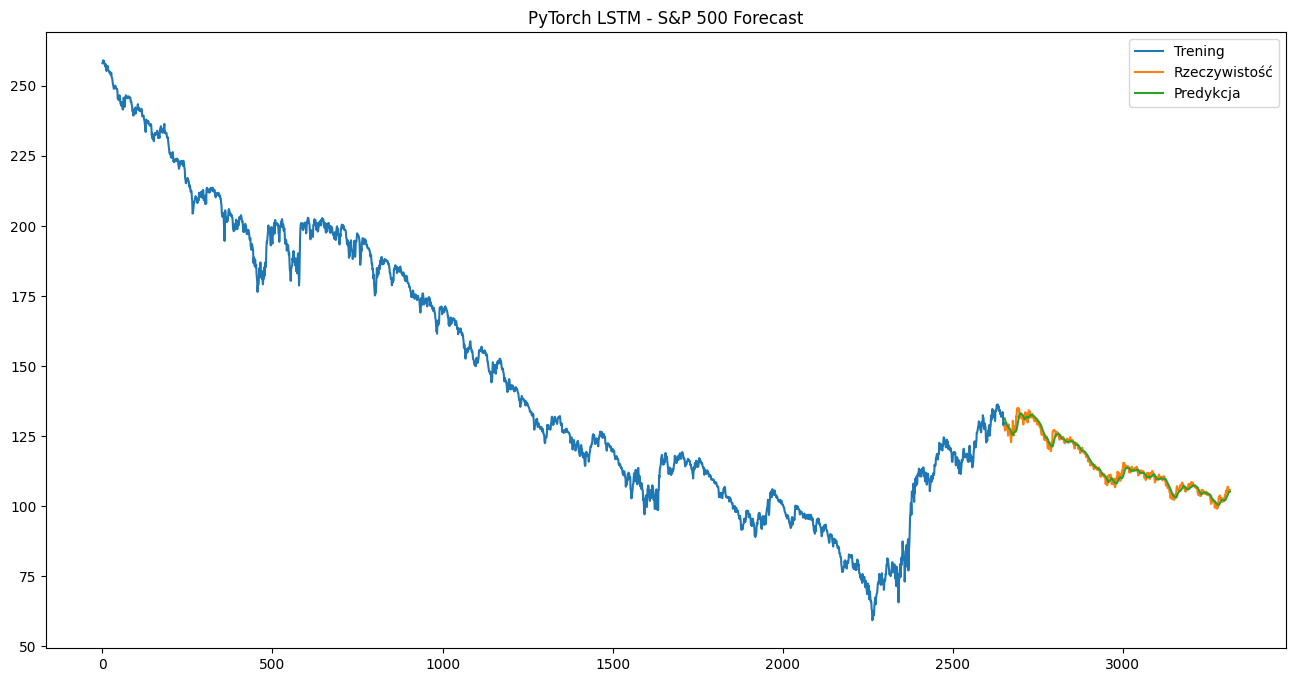

Błąd RMSE: 1.4639605797778603


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# 1. Przygotowanie danych (analogicznie do poprzedniego przykładu)
try:
    df = pd.read_csv('spy.csv')
except FileNotFoundError:
    print("Błąd: Nie znaleziono pliku sky.csv.")
    exit()

data = df.filter(['Close']).values
training_data_len = int(np.ceil(len(data) * .8))

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Tworzenie okna czasowego (60 dni)
window_size = 60
train_data = scaled_data[0:training_data_len, :]

x_train, y_train = [], []
for i in range(window_size, len(train_data)):
    x_train.append(train_data[i-window_size:i, 0])
    y_train.append(train_data[i, 0])

# Konwersja na Tensory PyTorch
# LSTM w PyTorch oczekuje kształtu: (batch, seq_len, input_size)
x_train = torch.tensor(np.array(x_train), dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32).unsqueeze(-1)

# 2. Definicja Architektury Modelu
class LSTMNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMNet, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # batch_first=True oznacza, że pierwszy wymiar to wielkość paczki danych
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1) # Warstwa wyjściowa

    def forward(self, x):
        # Inicjalizacja stanów ukrytych (h0 i c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        # Forward pass przez LSTM
        out, _ = self.lstm(x, (h0, c0))
        # Pobieramy wynik tylko z ostatniego kroku czasowego
        out = self.fc(out[:, -1, :])
        return out

model = LSTMNet()
criterion = nn.MSELoss() # Funkcja straty
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. Pętla Treningowa
epochs = 10
batch_size = 32

print("Rozpoczynanie treningu (PyTorch)...")
for epoch in range(epochs):
    model.train()
    # Prosta implementacja paczek (mini-batches)
    permutation = torch.randperm(x_train.size(0))
    
    epoch_loss = 0
    for i in range(0, x_train.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_train[indices], y_train[indices]
        
        # Reset gradientów
        optimizer.zero_grad()
        # Predykcja
        outputs = model(batch_x)
        # Obliczenie błędu
        loss = criterion(outputs, batch_y)
        # Backpropagation
        loss.backward()
        # Aktualizacja wag
        optimizer.step()
        
        epoch_loss += loss.item()
    
    if (epoch+1) % 2 == 0:
        print(f'Epoka [{epoch+1}/{epochs}], Strata: {epoch_loss/len(x_train):.6f}')

# 4. Przygotowanie danych testowych
test_data = scaled_data[training_data_len - window_size:, :]
x_test = []
y_actual = data[training_data_len:, :]

for i in range(window_size, len(test_data)):
    x_test.append(test_data[i-window_size:i, 0])

x_test = torch.tensor(np.array(x_test), dtype=torch.float32).unsqueeze(-1)

# 5. Predykcja
model.eval() # Tryb ewaluacji
with torch.no_grad():
    predictions = model(x_test).numpy()
    predictions = scaler.inverse_transform(predictions)

# 6. Wizualizacja
train = df.filter(['Close'])[:training_data_len]
valid = df.filter(['Close'])[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('PyTorch LSTM - S&P 500 Forecast')
plt.plot(train['Close'], label='Trening')
plt.plot(valid['Close'], label='Rzeczywistość')
plt.plot(valid['Predictions'], label='Predykcja')
plt.legend()
plt.show()

rmse = np.sqrt(np.mean(((predictions - y_actual) ** 2)))
print(f"Błąd RMSE: {rmse}")

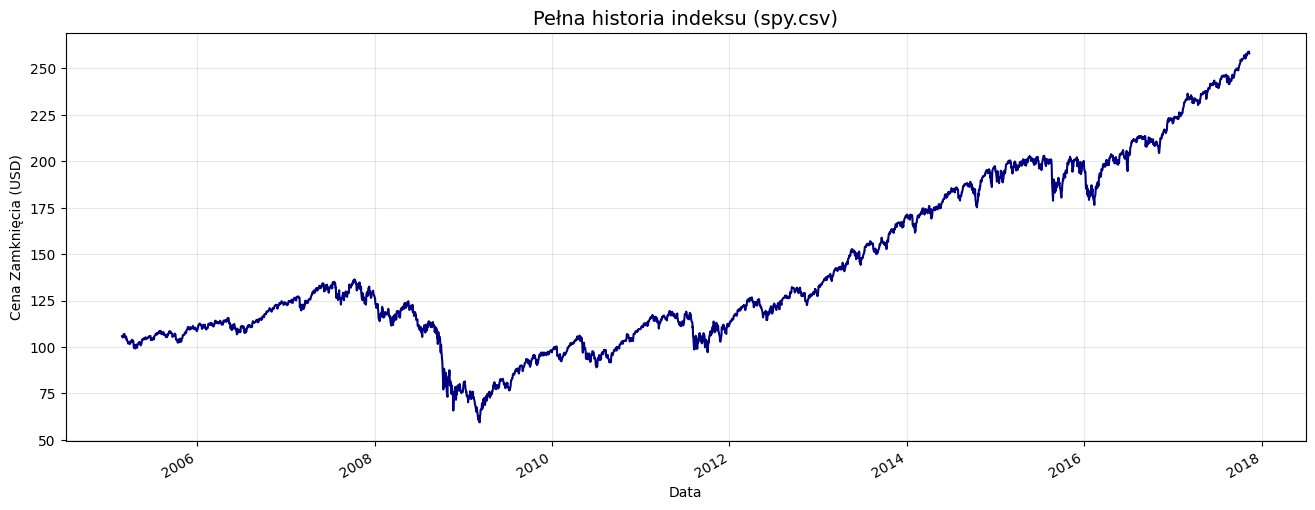

Trenowanie modelu...
Epoka 5/15, Loss: 0.057805
Epoka 10/15, Loss: 0.025038
Epoka 15/15, Loss: 0.028689


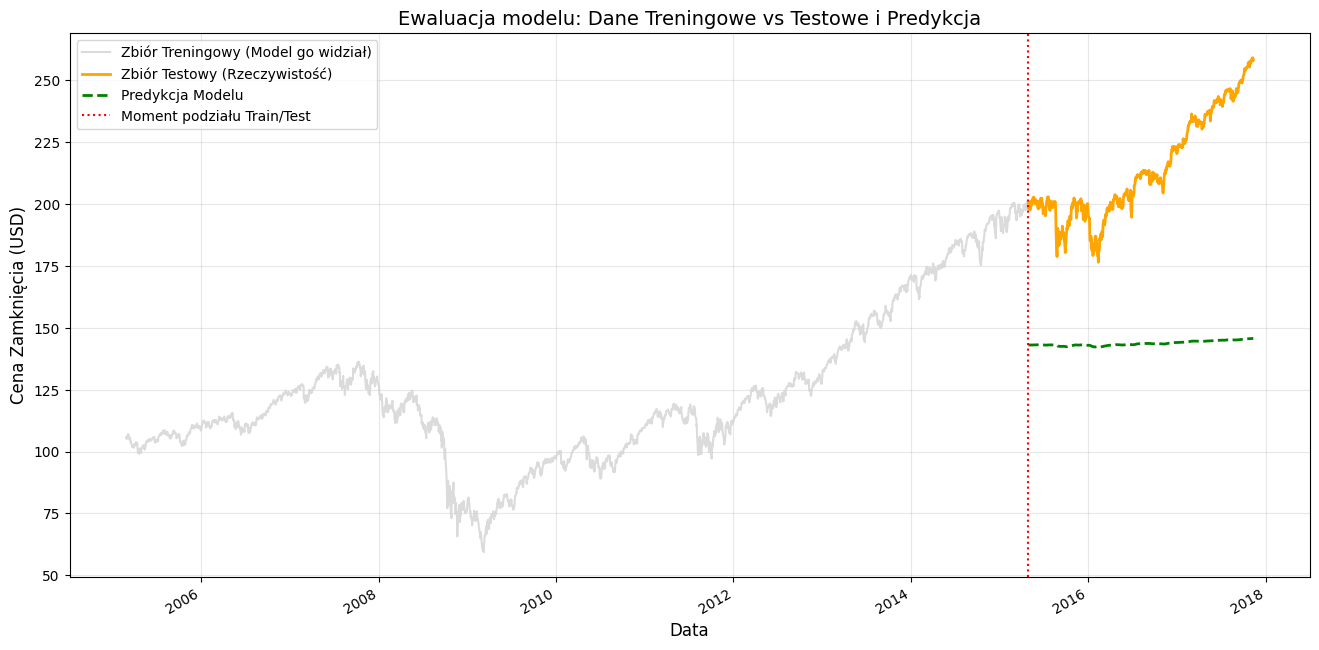

Błąd końcowy RMSE: 73.23 USD


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# --- 1. WCZYTANIE I PRZYGOTOWANIE DANYCH ---
file_name = 'spy.csv' # Zmień na 'spy.csv' jeśli tak nazywa się Twój plik
try:
    df = pd.read_csv(file_name)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df = df.sort_index()
except Exception as e:
    print(f"Błąd: {e}")
    exit()

# WYKRES 1: Pełna historia danych (Wstępna wizualizacja)
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['Close'], color='navy', linewidth=1.5)
plt.title(f'Pełna historia indeksu ({file_name})', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Cena Zamknięcia (USD)')
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

# --- 2. PREPROCESING ---
data = df.filter(['Close']).values
training_data_len = int(np.ceil(len(data) * .8))

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

window_size = 60
train_data = scaled_data[0:training_data_len, :]

x_train, y_train = [], []
for i in range(window_size, len(train_data)):
    x_train.append(train_data[i-window_size:i, 0])
    y_train.append(train_data[i, 0])

x_train = torch.tensor(np.array(x_train), dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32).unsqueeze(-1)

# --- 3. MODEL I TRENING ---
class LSTMNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = LSTMNet()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Trenowanie modelu...")
epochs = 15
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoka {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# --- 4. PREDYKCJA ---
test_data = scaled_data[training_data_len - window_size:, :]
x_test = []
y_actual = data[training_data_len:, :]

for i in range(window_size, len(test_data)):
    x_test.append(test_data[i-window_size:i, 0])

x_test = torch.tensor(np.array(x_test), dtype=torch.float32).unsqueeze(-1)

model.eval()
with torch.no_grad():
    predictions = model(x_test).numpy()
    predictions = scaler.inverse_transform(predictions)

# --- 5. WYKRES 2: PORÓWNANIE WYNIKÓW (TRENING vs TEST) ---
train_plot = df.filter(['Close'])[:training_data_len]
valid_plot = df.filter(['Close'])[training_data_len:].copy()
valid_plot['Predictions'] = predictions

plt.figure(figsize=(16, 8))
plt.title('Ewaluacja modelu: Dane Treningowe vs Testowe i Predykcja', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Cena Zamknięcia (USD)', fontsize=12)

# Rysujemy dane treningowe
plt.plot(train_plot.index, train_plot['Close'], label='Zbiór Treningowy (Model go widział)', color='lightgray', alpha=0.8)

# Rysujemy dane testowe (rzeczywiste)
plt.plot(valid_plot.index, valid_plot['Close'], label='Zbiór Testowy (Rzeczywistość)', color='orange', linewidth=2)

# Rysujemy predykcję
plt.plot(valid_plot.index, valid_plot['Predictions'], label='Predykcja Modelu', color='green', linestyle='--', linewidth=2)

plt.axvline(x=train_plot.index[-1], color='red', linestyle=':', label='Moment podziału Train/Test')
plt.grid(True, alpha=0.3)
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()

rmse = np.sqrt(np.mean(((predictions - y_actual) ** 2)))
print(f"Błąd końcowy RMSE: {rmse:.2f} USD")

Trenowanie na Twoim formacie danych...
Epoka 10/50, Loss: 0.000220
Epoka 20/50, Loss: 0.000545
Epoka 30/50, Loss: 0.000312
Epoka 40/50, Loss: 0.000320
Epoka 50/50, Loss: 0.000205


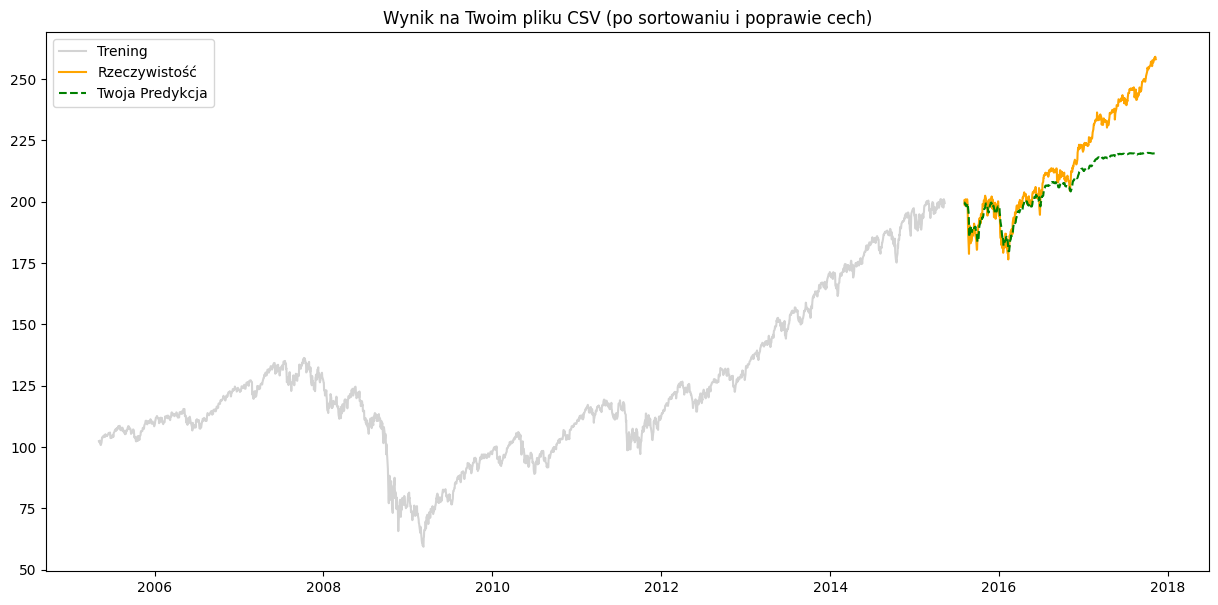

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# --- USTAW DEWICE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. WCZYTANIE I SORTOWANIE DANYCH ---
file_name = 'spy.csv' 
try:
    df = pd.read_csv(file_name)
    
    # 1. Konwersja daty
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # 2. KLUCZOWE: Odwrócenie danych, aby były chronologiczne (od najstarszych)
    df = df.sort_index(ascending=True)

    # 3. Feature Engineering (małe litery jak w Twoim pliku)
    df['SMA20'] = df['close'].rolling(window=20).mean()
    df['SMA50'] = df['close'].rolling(window=50).mean()
    df.dropna(inplace=True) 

except Exception as e:
    print(f"Błąd wczytywania: {e}")
    exit()

# Wybór cech (dokładnie takie nazwy jak na screenie)
feature_cols = ['open', 'high', 'low', 'close', 'volume', 'SMA20', 'SMA50']
input_size = len(feature_cols)

# --- 2. SKALOWANIE ---
raw_data = df[feature_cols].values
close_data = df['close'].values.reshape(-1, 1)

training_data_len = int(np.ceil(len(raw_data) * .8))

scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_features_train = scaler_features.fit_transform(raw_data[:training_data_len])
scaled_features_test = scaler_features.transform(raw_data[training_data_len:])

scaler_target = MinMaxScaler(feature_range=(0, 1))
scaled_target_train = scaler_target.fit_transform(close_data[:training_data_len])
scaled_target_test = scaler_target.transform(close_data[training_data_len:])

# Okno czasowe
window_size = 60

def create_sequences(data_x, data_y, window):
    x, y = [], []
    for i in range(window, len(data_x)):
        x.append(data_x[i-window:i])
        y.append(data_y[i, 0])
    return np.array(x), np.array(y)

x_train, y_train = create_sequences(scaled_features_train, scaled_target_train, window_size)
x_test, y_test_scaled = create_sequences(scaled_features_test, scaled_target_test, window_size)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1).to(device)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)

# --- 3. MODEL (Z LayerNorm dla lepszej stabilności) ---
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super(EnhancedLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.ln = nn.LayerNorm(hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.ln(out[:, -1, :])
        return self.fc(out)

model = EnhancedLSTM(input_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # Mniejszy LR dla stabilności
criterion = nn.MSELoss()

# --- 4. TRENING (Więcej epok) ---
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

print("Trenowanie na Twoim formacie danych...")
for epoch in range(50): # Zwiększ do 100 jeśli masz czas
    model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoka {epoch+1}/50, Loss: {loss.item():.6f}")

# --- 5. PREDYKCJA ---
model.eval()
with torch.no_grad():
    pred_scaled = model(x_test_tensor).cpu().numpy()
predictions = scaler_target.inverse_transform(pred_scaled)
y_actual = close_data[training_data_len + window_size:]

# --- 6. WYKRES ---
valid_plot = df.filter(['close'])[training_data_len + window_size:].copy()
valid_plot['Predictions'] = predictions

plt.figure(figsize=(15, 7))
plt.plot(df['close'][:training_data_len], label='Trening', color='lightgray')
plt.plot(valid_plot['close'], label='Rzeczywistość', color='orange')
plt.plot(valid_plot['Predictions'], label='Twoja Predykcja', color='green', linestyle='--')
plt.title('Wynik na Twoim pliku CSV (po sortowaniu i poprawie cech)')
plt.legend()
plt.show()

Trenowanie...


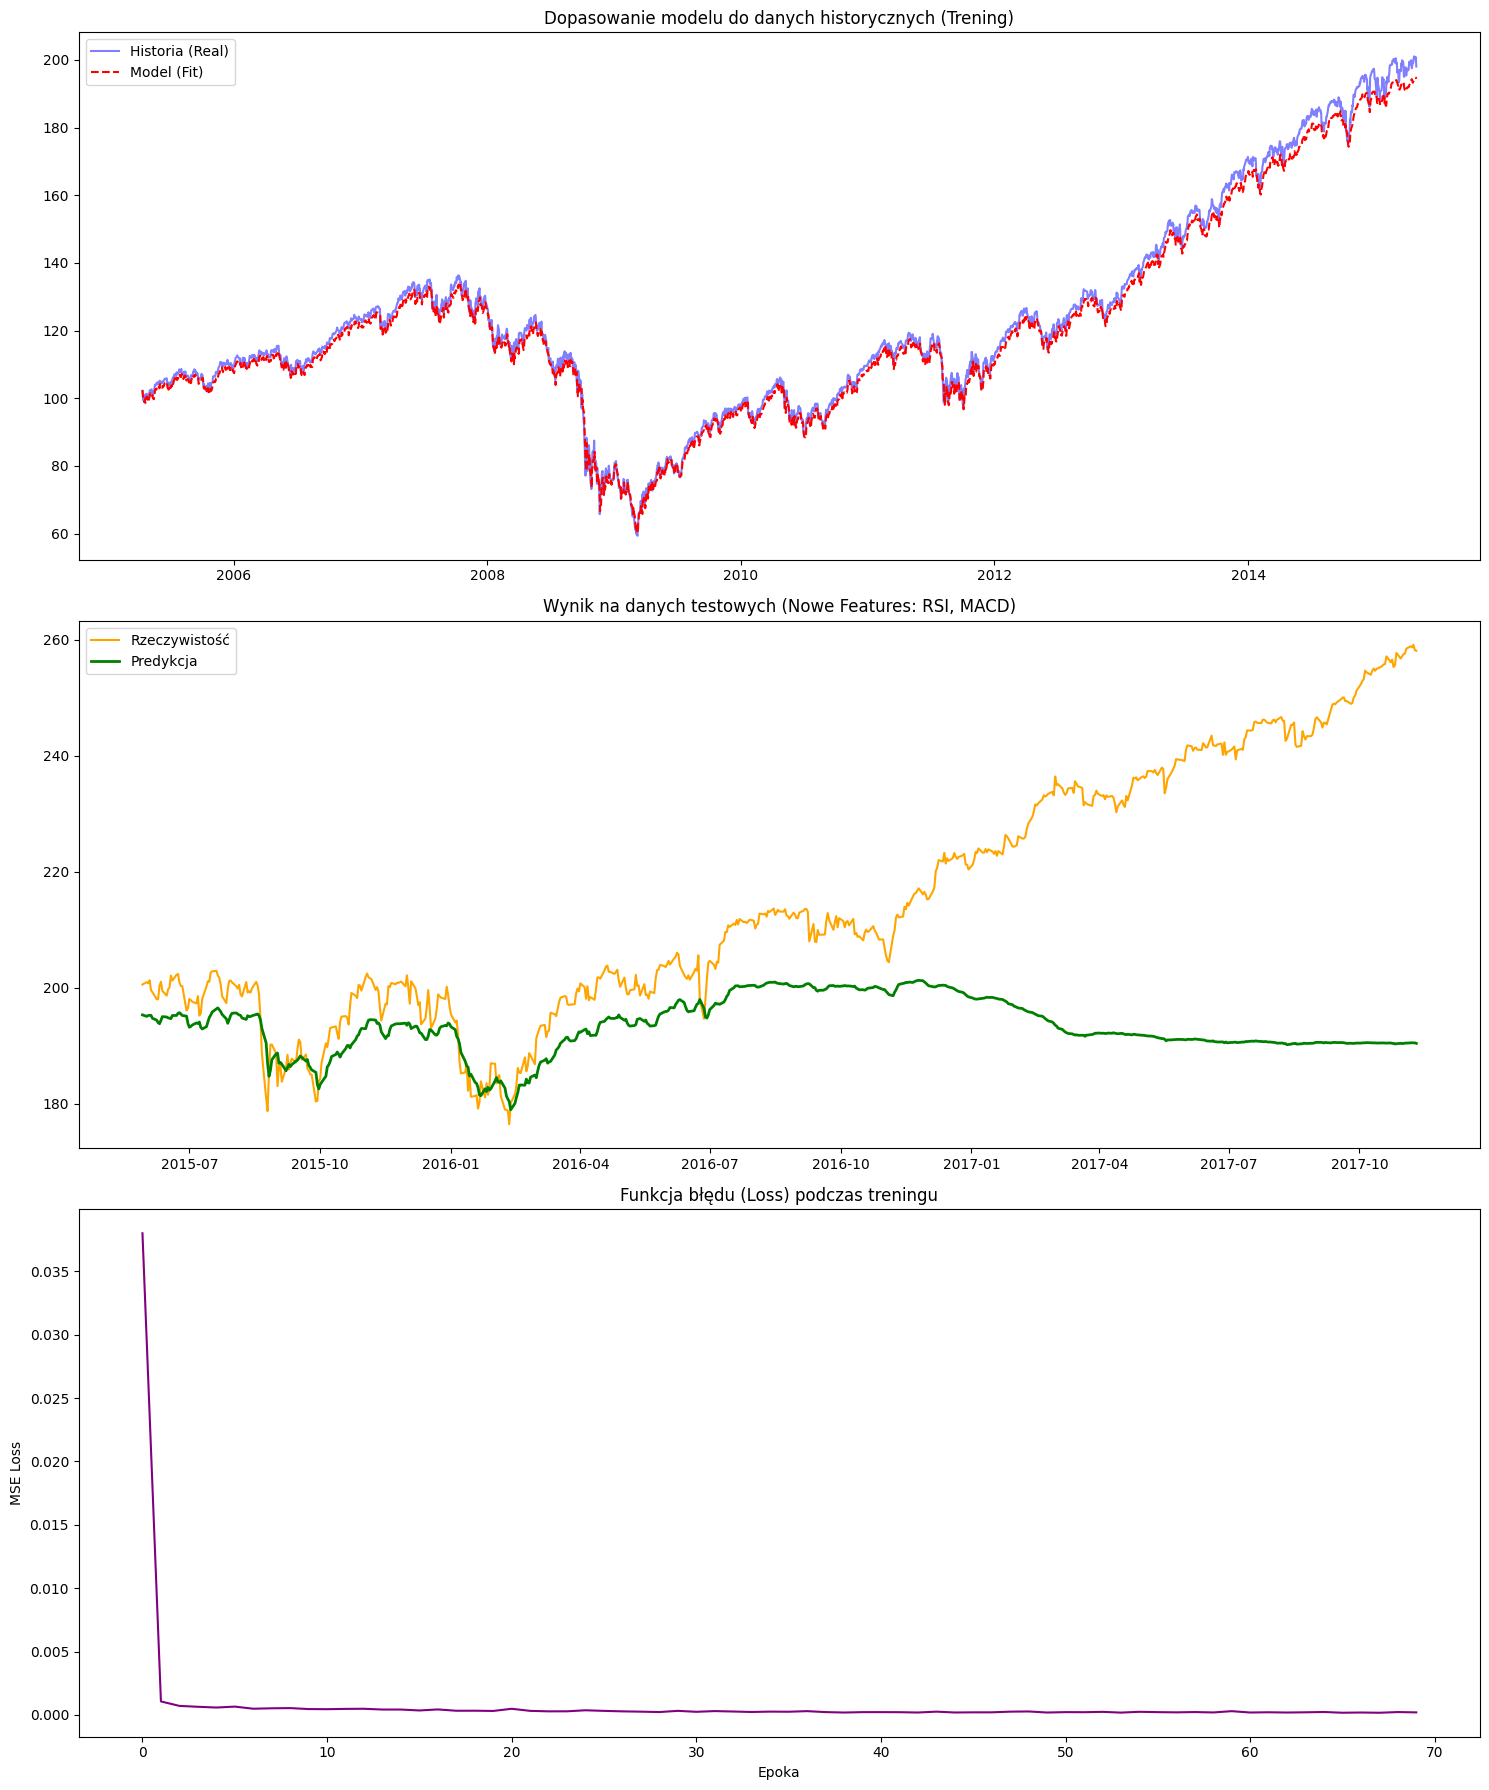

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. FEATURE ENGINEERING (NAJLEPSZE DLA ETF) ---
def add_indicators(df):
    # RSI - Wskaźnik siły relatywnej (czy rynek jest wykupiony/wyprzedany)
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD - Trend (Różnica średnich)
    exp1 = df['close'].ewm(span=12, adjust=False).mean()
    exp2 = df['close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    
    # Zmienność (Daily Returns) - bardzo pomaga w nauce dynamiki
    df['Returns'] = df['close'].pct_change()
    
    df.dropna(inplace=True)
    return df

# --- 2. PRZYGOTOWANIE DANYCH ---
df = pd.read_csv('spy.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index(ascending=True)
df = add_indicators(df)

# Wybrane cechy: kluczowe dla SPY
feature_cols = ['close', 'volume', 'RSI', 'MACD', 'Returns']
input_size = len(feature_cols)

# Skalowanie
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

train_size = int(len(df) * 0.8)
train_df = df[:train_size]
test_df = df[train_size:]

scaled_x_train = scaler_x.fit_transform(train_df[feature_cols])
scaled_y_train = scaler_y.fit_transform(train_df[['close']])
scaled_x_test = scaler_x.transform(test_df[feature_cols])
scaled_y_test = scaler_y.transform(test_df[['close']])

window_size = 20
def create_seq(x, y, window):
    xs, ys = [], []
    for i in range(window, len(x)):
        xs.append(x[i-window:i])
        ys.append(y[i])
    return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)

x_train, y_train = create_seq(scaled_x_train, scaled_y_train, window_size)
x_test, y_test = create_seq(scaled_x_test, scaled_y_test, window_size)

# --- 3. MODEL I TRENING ---
class SPY_LSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 128, num_layers=3, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = SPY_LSTM(input_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

history = []
print("Trenowanie...")
for epoch in range(70):
    model.train()
    epoch_loss = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        pred = model(bx)
        loss = criterion(pred, by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    history.append(epoch_loss/len(train_loader))

# --- 4. PREDYKCJA I ANALIZA ---
model.eval()
with torch.no_grad():
    train_preds = scaler_y.inverse_transform(model(x_train.to(device)).cpu().numpy())
    test_preds = scaler_y.inverse_transform(model(x_test.to(device)).cpu().numpy())

# --- 5. POTRÓJNY WYKRES ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18))

# Wykres 1: Trening (Dopasowanie do historii)
ax1.plot(train_df.index[window_size:], train_df['close'][window_size:], label='Historia (Real)', color='blue', alpha=0.5)
ax1.plot(train_df.index[window_size:], train_preds, label='Model (Fit)', color='red', linestyle='--')
ax1.set_title('Dopasowanie modelu do danych historycznych (Trening)')
ax1.legend()

# Wykres 2: Test (To, co widziałeś wcześniej, ale ulepszone)
ax2.plot(test_df.index[window_size:], test_df['close'][window_size:], label='Rzeczywistość', color='orange')
ax2.plot(test_df.index[window_size:], test_preds, label='Predykcja', color='green', linewidth=2)
ax2.set_title('Wynik na danych testowych (Nowe Features: RSI, MACD)')
ax2.legend()

# Wykres 3: Funkcja błędu (Czy model się uczył?)
ax3.plot(history, color='purple')
ax3.set_title('Funkcja błędu (Loss) podczas treningu')
ax3.set_xlabel('Epoka')
ax3.set_ylabel('MSE Loss')

plt.tight_layout()
plt.show()

Dopasowywanie modelu ARIMA...


/Users/mrkarol/Documents/Studia/Sem_8/ML/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/mrkarol/Documents/Studia/Sem_8/ML/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/mrkarol/Documents/Studia/Sem_8/ML/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


Dopasowywanie modelu EGARCH na residuach ARIMA...
Generowanie predykcji testowej...


/Users/mrkarol/Documents/Studia/Sem_8/ML/.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001526. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


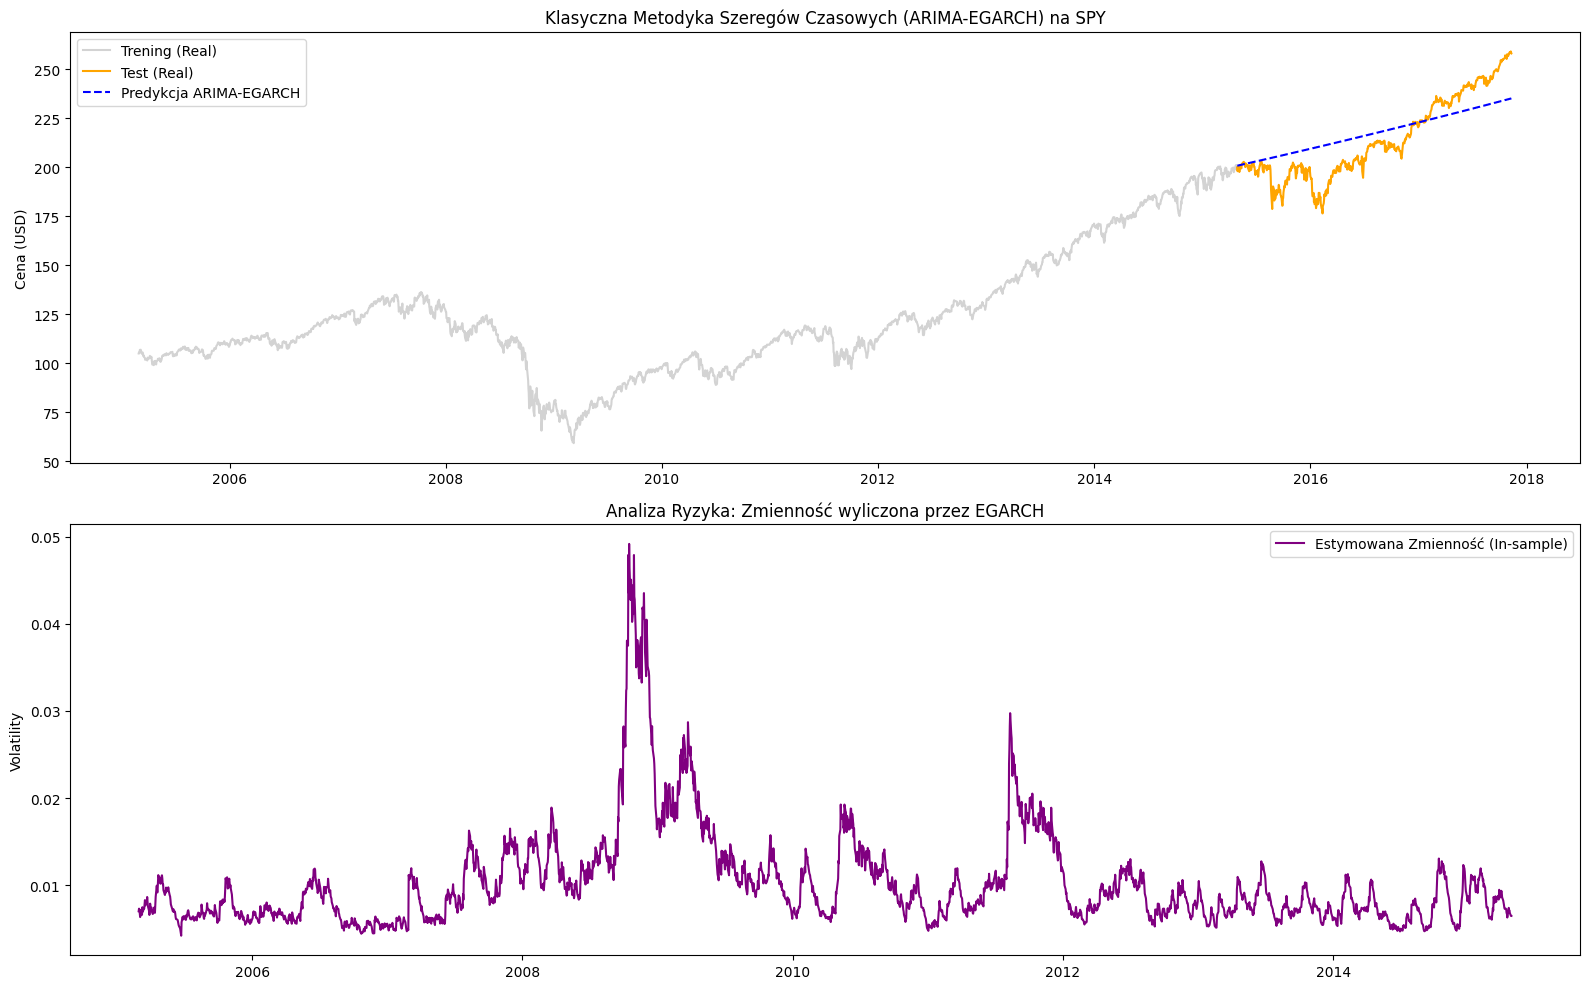

Błąd RMSE (ARIMA): 12.86 USD


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import mean_squared_error

# 1. PRZYGOTOWANIE DANYCH
df = pd.read_csv('spy.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index(ascending=True)

# Modele klasyczne najlepiej działają na log-zwrotach (stacjonarność)
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)

# Podział 80/20
train_size = int(len(df) * 0.8)
train_data = df['log_return'][:train_size]
test_data = df['log_return'][train_size:]

# 2. MODELOWANIE ŚREDNIEJ (ARIMA)
# Wybieramy model (p, d, q). Dla log-zwrotów d=0, bo są już stacjonarne.
# ARIMA(5,0,0) oznacza, że patrzymy na 5 ostatnich dni.
print("Dopasowywanie modelu ARIMA...")
arima_model = ARIMA(train_data, order=(5, 0, 0))
arima_result = arima_model.fit()

# 3. MODELOWANIE ZMIENNOŚCI (EGARCH)
# EGARCH jest lepszy od zwykłego GARCH, bo uwzględnia asymetrię (spadki bolą bardziej)
print("Dopasowywanie modelu EGARCH na residuach ARIMA...")
egarch_model = arch_model(arima_result.resid, vol='EGARCH', p=1, q=1)
egarch_result = egarch_model.fit(disp='off')

# 4. PREDYKCJA NA ZBIORZE TESTOWYM
# W klasycznej statystyce często używa się "rolling forecast" (krok po kroku)
# Tutaj zrobimy predykcję statyczną dla porównania z Twoim LSTM
history = list(train_data)
predictions_log = []

print("Generowanie predykcji testowej...")
# Uproszczona predykcja dla szybkości (out-of-sample forecast)
arima_forecast = arima_result.get_forecast(steps=len(test_data))
predictions_log = arima_forecast.predicted_mean

# Powrót z log-zwrotów do cen (bazując na ostatniej cenie treningowej)
last_train_price = df['close'].iloc[train_size-1]
# Skumulowane zwroty pozwalają odtworzyć ścieżkę ceny
predicted_prices = last_train_price * np.exp(np.cumsum(predictions_log))

# 5. WIZUALIZACJA
plt.figure(figsize=(16, 10))

# Wykres 1: Ceny
plt.subplot(2, 1, 1)
plt.plot(df.index[:train_size], df['close'][:train_size], label='Trening (Real)', color='lightgray')
plt.plot(df.index[train_size:], df['close'][train_size:], label='Test (Real)', color='orange')
plt.plot(df.index[train_size:], predicted_prices, label='Predykcja ARIMA-EGARCH', color='blue', linestyle='--')
plt.title('Klasyczna Metodyka Szeregów Czasowych (ARIMA-EGARCH) na SPY')
plt.ylabel('Cena (USD)')
plt.legend()

# Wykres 2: Zmienność (Warunkowe odchylenie standardowe z EGARCH)
plt.subplot(2, 1, 2)
# Wyświetlamy przewidywaną zmienność (volatility)
vol = egarch_result.conditional_volatility
plt.plot(train_data.index, vol, label='Estymowana Zmienność (In-sample)', color='purple')
plt.title('Analiza Ryzyka: Zmienność wyliczona przez EGARCH')
plt.ylabel('Volatility')
plt.legend()

plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(df['close'][train_size:], predicted_prices))
print(f"Błąd RMSE (ARIMA): {rmse:.2f} USD")

Obliczanie Rolling ARIMA dla 200 dni...
Obliczanie modelu EGARCH...


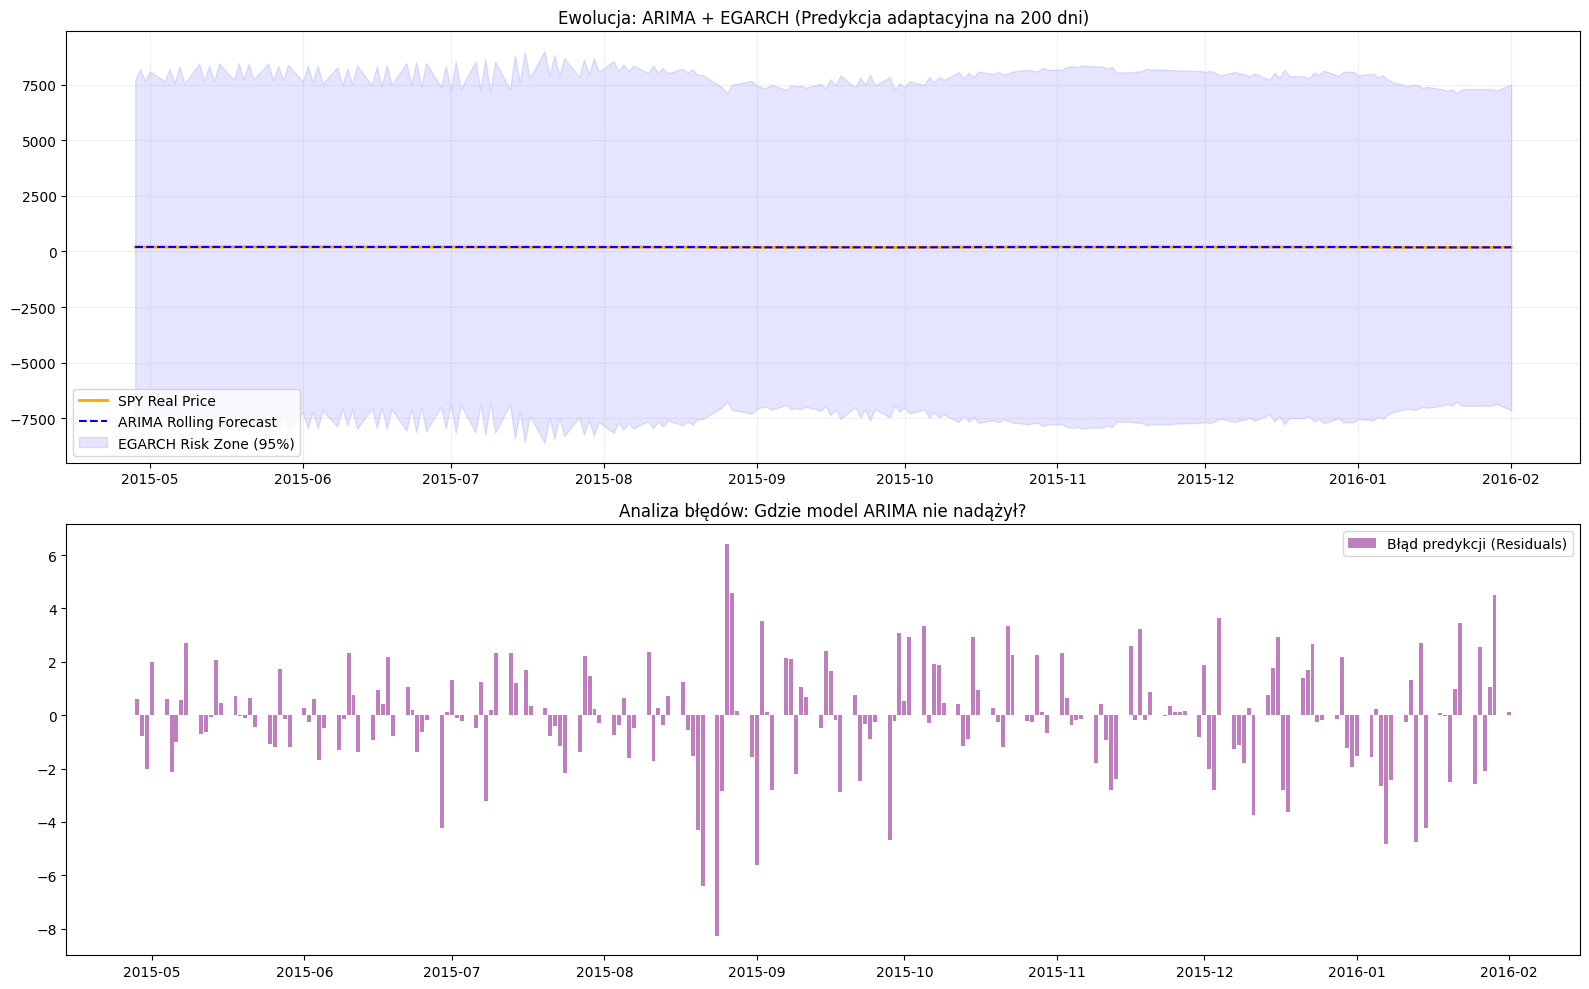

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# 1. PRZYGOTOWANIE DANYCH
df = pd.read_csv('spy.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index(ascending=True)

# Podział 80/20
train_size = int(len(df) * 0.8)
train_data = df['close'][:train_size]
test_data = df['close'][train_size:]

# Dynamiczne ustawienie limitu - zapobiega IndexError
test_limit = min(200, len(test_data)) 
actual_values = test_data[:test_limit]

# --- ETAP 1: ROLLING ARIMA (Sama Średnia) ---
print(f"Obliczanie Rolling ARIMA dla {test_limit} dni...")
history = [x for x in train_data]
arima_preds = []

for t in range(test_limit):
    model = ARIMA(history, order=(5,1,0))
    res = model.fit()
    arima_preds.append(res.forecast()[0])
    history.append(test_data.iloc[t]) # Uczymy model na nowym dniu

# --- ETAP 2: EGARCH (Analiza Zmienności/Szumu) ---
# Skupiamy się na log-zwrotach, bo EGARCH bada "szoki" cenowe
print("Obliczanie modelu EGARCH...")
returns = np.log(df['close'] / df['close'].shift(1)).dropna()
train_returns = returns[:train_size]

# EGARCH(1,1) - złoty standard dla S&P 500
egarch_m = arch_model(train_returns, vol='EGARCH', p=1, q=1, dist='t')
egarch_res = egarch_m.fit(disp='off')

# Wyliczamy przedziały ufności (Confidence Intervals)
# One pokazują, gdzie cena MOŻE się znaleźć wg statystyki
volatility = egarch_res.conditional_volatility[-test_limit:]
upper_bound = np.array(arima_preds) + (1.96 * volatility * np.array(arima_preds))
lower_bound = np.array(arima_preds) - (1.96 * volatility * np.array(arima_preds))

# --- 2. WIZUALIZACJA PORÓWNAWCZA ---
plt.figure(figsize=(16, 10))

# Wykres główny: Predykcja vs Rzeczywistość
plt.subplot(2, 1, 1)
plt.plot(actual_values.index, actual_values, label='SPY Real Price', color='orange', linewidth=2)
plt.plot(actual_values.index, arima_preds, label='ARIMA Rolling Forecast', color='blue', linestyle='--')

# Dodajemy "Pasmo Strachu" z EGARCH
plt.fill_between(actual_values.index, lower_bound, upper_bound, color='blue', alpha=0.1, label='EGARCH Risk Zone (95%)')

plt.title(f'Ewolucja: ARIMA + EGARCH (Predykcja adaptacyjna na {test_limit} dni)')
plt.legend()
plt.grid(True, alpha=0.2)

# Wykres dolny: Residua (czego model nie przewidział)
plt.subplot(2, 1, 2)
residuals = actual_values - arima_preds
plt.bar(actual_values.index, residuals, color='purple', alpha=0.5, label='Błąd predykcji (Residuals)')
plt.title('Analiza błędów: Gdzie model ARIMA nie nadążył?')
plt.legend()

plt.tight_layout()
plt.show()

ADF Statistic: -2.7971961858103698, p-value: 0.05867539046443457
                            AutoReg Model Results                             
Dep. Variable:                  close   No. Observations:                 3315
Model:                     AutoReg(1)   Log Likelihood               -5655.144
Method:               Conditional MLE   S.D. of innovations              1.333
Date:                Sun, 12 Apr 2026   AIC                          11316.288
Time:                        15:20:24   BIC                          11334.606
Sample:                             1   HQIC                         11322.843
                                 3315                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0482      0.023     -2.078      0.038      -0.094      -0.003
close.L1      -0.0471      0.017     -2.715      0.007      -0.081

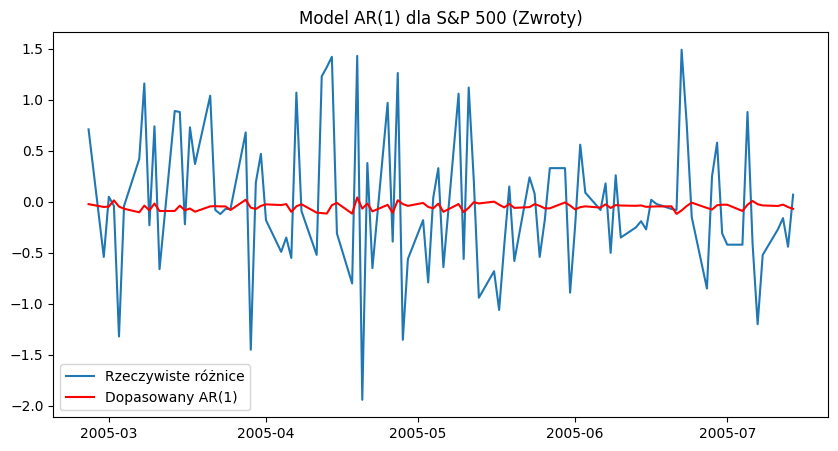

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller

# 1. Wczytanie danych
df = pd.read_csv('spy.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
close_prices = df['close']

# 2. Sprawdzenie stacjonarności (Ceny są zazwyczaj niestacjonarne)
result = adfuller(close_prices)
print(f'ADF Statistic: {result[0]}, p-value: {result[1]}')

# 3. Przekształcenie na stacjonarne (Różnice dzienne)
returns = close_prices.diff().dropna()

# 4. Budowa modelu AR(1) na zwrotach
# Wybieramy rząd opóźnienia p=1 (można dobrać za pomocą kryterium AIC/BIC)
model = AutoReg(returns, lags=1)
model_fit = model.fit()

# Wyniki modelu
print(model_fit.summary())

# 5. Wizualizacja
plt.figure(figsize=(10,5))
plt.plot(returns.index[-100:], returns.values[-100:], label='Rzeczywiste różnice')
plt.plot(model_fit.fittedvalues[-100:], color='red', label='Dopasowany AR(1)')
plt.title('Model AR(1) dla S&P 500 (Zwroty)')
plt.legend()
plt.show()

R2 Score: -0.0148
MSE: 0.0001


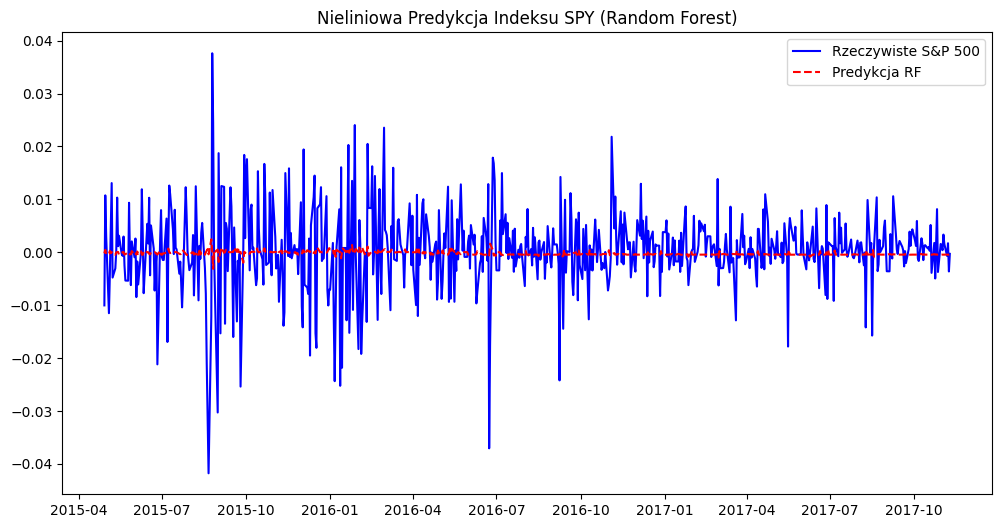

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Ładowanie danych
# Zakładamy, że plik ma kolumny 'date' i 'Close'
df = pd.read_csv('spy.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

# 2. Feature Engineering (Tworzenie cech nieliniowych)
# Model musi wiedzieć, co działo się wcześniej, by przewidzieć przyszłość
# Przewiduj logarytmiczną stopę zwrotu:
df['Return'] = np.log(df['close'] / df['close'].shift(1))
df['Target'] = df['Return'].shift(-1)
df['Lag_1'] = df['close'].shift(1)    # Cena z wczoraj
df['Lag_5'] = df['close'].shift(5)    # Cena sprzed tygodnia
df['MA_10'] = df['close'].rolling(window=10).mean() # Średnia z 10 dni
df['Daily_Return'] = df['close'].pct_change()        # Dzienna stopa zwrotu

df.dropna(inplace=True) # Usuwamy puste wiersze powstałe przez przunięcia

# 3. Podział na zbiór treningowy i testowy (Chronologiczny!)
features = ['close', 'Lag_1', 'Lag_5', 'MA_10', 'Daily_Return']
X = df[features]
y = df['Target']

split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 4. Model nieliniowy: Random Forest
# n_estimators - liczba drzew (im więcej, tym stabilniej, ale wolniej)
# max_depth - ograniczenie głębokości, by nie "przeuczyć" modelu
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 5. Predykcja i wyniki
predictions = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, predictions):.4f}")
print(f"MSE: {mean_squared_error(y_test, predictions):.4f}")

# 6. Wizualizacja
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Rzeczywiste S&P 500', color='blue')
plt.plot(y_test.index, predictions, label='Predykcja RF', color='red', linestyle='--')
plt.title('Nieliniowa Predykcja Indeksu SPY (Random Forest)')
plt.legend()
plt.show()